# 1. Model Definition — `MultiModalRowTransformer`

Self-supervised transformer for multimodal tabular + text bridge data. Each feature token is the sum of three learned vectors: a value projection, a feature identity embedding, and a modality type embedding (numeric / categorical / text). A prepended CLS token aggregates cross-feature context through the transformer encoder and is used as the input to both SCCI prediction heads.

Two operating modes share the same encoder:

**Pretrain mode** reconstructs masked numeric values (MSE) and masked categorical values (cross-entropy) from the unmasked context — no labels required, runs on all 4,914 NBI rows.

**Regress mode** passes the CLS representation through two parallel heads: a quantile head (pinball loss at α=0.10, producing 90% prediction intervals) and a point head (MSE). Both heads predict SCCI directly.

In [1]:
import torch
import numpy as np
import random

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F


def pinball_loss(y, q, alpha):
    r = y - q
    return torch.mean(torch.where(r >= 0, alpha * r, (alpha - 1) * r))


class MultiModalRowTransformer(nn.Module):
    def __init__(
        self,
        num_feature_names,
        cat_feature_names,
        cat_vocab_sizes,
        text_vocab_size,
        d_model:      int   = 128,
        nhead:        int   = 8,
        num_layers:   int   = 4,
        max_text_len: int   = 128,
        dropout:      float = 0.1,
    ):
        super().__init__()

        # 1. Feature bookkeeping
        self.num_feature_names = num_feature_names
        self.cat_feature_names = cat_feature_names
        self.N_num             = len(num_feature_names)
        self.N_cat             = len(cat_feature_names)
        self.d_model           = d_model
        self.max_text_len      = max_text_len

        # 2. Trinity embeddings
        self.type_emb       = nn.Embedding(3, d_model)
        self.all_feat_names = num_feature_names + cat_feature_names
        self.feature_to_id  = {name: i for i, name in enumerate(self.all_feat_names)}
        self.feature_emb    = nn.Embedding(len(self.all_feat_names), d_model)

        # 3. Value projections
        self.num_proj     = nn.ModuleList([nn.Linear(1, d_model) for _ in range(self.N_num)])
        self.cat_val_emb  = nn.ModuleList([nn.Embedding(vsz, d_model) for vsz in cat_vocab_sizes])
        self.text_tok_emb = nn.Embedding(text_vocab_size, d_model)
        self.text_pos_emb = nn.Embedding(max_text_len, d_model)

        # 4. CLS token + dropout
        self.cls_token   = nn.Parameter(torch.randn(1, 1, d_model))
        self.cls_dropout = nn.Dropout(0.1)

        # 5. Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=d_model * 4,
            dropout=dropout, batch_first=True, activation='gelu',
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # 6. SCCI heads
        # Quantile head — outputs [q_lo_raw, gap_raw], pinball loss
        self.scci_head = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.Dropout(0.3),
            nn.GELU(),
            nn.Linear(d_model // 2, 2),
        )
        # Point head — scalar, MSE loss
        self.scci_point_head = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.Dropout(0.3),
            nn.GELU(),
            nn.Linear(d_model // 2, 1),
        )

        # 7. Pretraining reconstruction heads
        self.num_recon = nn.ModuleList([nn.Linear(d_model, 1) for _ in range(self.N_num)])
        self.cat_recon = nn.ModuleList([nn.Linear(d_model, vsz - 1) for vsz in cat_vocab_sizes])

    def _build_sequence(self, num_x, cat_x, text_ids):
        B      = num_x.shape[0]
        device = num_x.device
        tokens = []

        tokens.append(self.cls_token.expand(B, -1, -1))

        type_num = self.type_emb(torch.tensor([0], device=device))
        for i, name in enumerate(self.num_feature_names):
            val  = self.num_proj[i](num_x[:, i].unsqueeze(-1))
            feat = self.feature_emb(torch.tensor([self.feature_to_id[name]], device=device))
            tokens.append((val + feat + type_num).unsqueeze(1))

        type_cat = self.type_emb(torch.tensor([1], device=device))
        for i, name in enumerate(self.cat_feature_names):
            val  = self.cat_val_emb[i](cat_x[:, i])
            feat = self.feature_emb(torch.tensor([self.feature_to_id[name]], device=device))
            tokens.append((val + feat + type_cat).unsqueeze(1))

        if text_ids is not None:
            type_txt = self.type_emb(torch.tensor([2], device=device))
            pos      = self.text_pos_emb(torch.arange(text_ids.size(1), device=device))
            tokens.append(self.text_tok_emb(text_ids) + pos + type_txt)

        return torch.cat(tokens, dim=1)

    def forward(
        self,
        num_x,
        cat_x,
        text_ids    = None,
        y_scci      = None,
        num_mask    = None,
        num_targets = None,
        cat_mask    = None,
        cat_targets = None,
        mode:                str   = 'regress',
        alpha:               float = 0.10,
        scci_pinball_weight: float = 1.0,
        scci_point_weight:   float = 1.0,
    ):
        X       = self._build_sequence(num_x, cat_x, text_ids)
        H       = self.transformer(X)
        cls_out = self.cls_dropout(H[:, 0])

        if mode == 'regress':
            # Quantile head
            scci_raw  = self.scci_head(cls_out)
            scci_q_lo = scci_raw[:, 0]
            scci_q_hi = scci_q_lo + F.softplus(scci_raw[:, 1])
            # Point head
            scci_point = self.scci_point_head(cls_out).squeeze(-1)

            loss = None
            if y_scci is not None:
                valid = ~torch.isnan(y_scci)
                total = torch.tensor(0.0, device=num_x.device)
                if valid.sum() > 0:
                    y_v    = y_scci[valid]
                    pb = (pinball_loss(y_v, scci_q_lo[valid], alpha / 2)
                          + pinball_loss(y_v, scci_q_hi[valid], 1.0 - alpha / 2))
                    total = total + scci_pinball_weight * pb
                    total = total + scci_point_weight * F.mse_loss(scci_point[valid], y_v)
                loss = total

            return {
                'scci_direct': {'q_lo': scci_q_lo, 'q_hi': scci_q_hi},
                'scci_point':  scci_point,
                'loss':        loss,
            }

        elif mode == 'pretrain':
            total_loss = torch.tensor(0.0, device=num_x.device)

            H_num = H[:, 1 : 1 + self.N_num, :]
            for i in range(self.N_num):
                mask = num_mask[:, i]
                if mask.any():
                    pred = self.num_recon[i](H_num[mask, i]).squeeze(-1)
                    total_loss = total_loss + F.mse_loss(pred, num_targets[mask, i])

            H_cat = H[:, 1 + self.N_num : 1 + self.N_num + self.N_cat, :]
            for i in range(self.N_cat):
                mask = cat_mask[:, i]
                if mask.any():
                    logits = self.cat_recon[i](H_cat[mask, i])
                    tgts   = cat_targets[mask, i].clamp(max=logits.shape[-1] - 1)
                    total_loss = total_loss + F.cross_entropy(logits, tgts)

            return {'loss': total_loss}

        else:
            raise ValueError(f"Unknown mode: {mode!r}")


# 2. Masking - Pretrain Collator

Generates masked inputs and reconstruction targets for Phase 1 self-supervised pretraining. For each batch, numeric features are independently masked with probability `p_num` (default 0.3) and categorical features with probability `p_cat` (default 0.3). Masked positions receive a learned mask embedding in place of their true value; the original values are stored as targets and only contribute to the loss at masked positions.

The masking is applied fresh each epoch rather than precomputed - this means the model sees different mask patterns on each pass through the data, acting as a form of data augmentation that is especially valuable given the small dataset size (4k rows). Numeric targets are passed as raw standardised values; categorical targets are passed as integer class indices for cross-entropy.



In [3]:
def create_masks(num_x, cat_x, mask_prob=0.15, cat_vocab_sizes=None):
    """
    num_x:           (B, N_num) float tensor
    cat_x:           (B, N_cat) int64 tensor
    cat_vocab_sizes: list[int] — vocab size per categorical column
                     Token layout: 0=UNKNOWN, 1..vsz-2=real, vsz-1=MASK
    """
    device  = num_x.device

    # Numeric
    num_mask     = torch.rand(num_x.shape, device=device) < mask_prob
    num_targets  = num_x.clone()
    num_x_masked = num_x.clone()
    num_x_masked[num_mask] = 0.0   # 0.0 ≈ mean for normalised features

    # Categorical — each column gets its own MASK token = vsz-1
    cat_mask     = torch.rand(cat_x.shape, device=device) < mask_prob
    cat_targets  = cat_x.clone()
    cat_x_masked = cat_x.clone()
    for i, vsz in enumerate(cat_vocab_sizes):
        cat_x_masked[cat_mask[:, i], i] = vsz - 1

    return num_x_masked, num_mask, num_targets, cat_x_masked, cat_mask, cat_targets

# 3. Data Loading — NBI Tensor Construction

Loads and aligns three NBI modalities (numerical, categorical, tokenised text) from disk, validates column order against metadata, and builds the full 4,914-row unlabelled tensor dataset used for Phase 1 pretraining.

Then matches the labeled dataset to NBI positions via `STRUCTURE_ID`, which is the first element of the composite `unified_id` used in the NBI data. Bridges where one structure ID maps to multiple NBI coordinate segments are dropped from fine-tuning — those bridges' NBI segments are retained in the unlabelled pool for Phase 1.

The resulting labeled dataset carries five tensors per row: NBI numeric features, NBI categorical features, tokenised text, SCCI target, and a boolean imputation flag.

In [4]:
import torch
import numpy as np
import pandas as pd
import json
import ast
from pathlib import Path
from collections import defaultdict
from torch.utils.data import TensorDataset

OMIT_IMPUTED = True

# ── PATHS ─────────────────────────────────────────────────────────────────────
# Notebook lives in  package/models/
# Data lives in      package/data/sst_ready/
BASE_DIR       = Path("../data")
CHECKPOINT_DIR = Path("../checkpoints")
CHECKPOINT_DIR.mkdir(exist_ok=True)

# 1. LOAD RAW DATA
with open(BASE_DIR / "metadata.json", "r", encoding="utf-8") as f:
    metadata = json.load(f)

numerical_df   = pd.read_csv(BASE_DIR / "numerical.csv")
categorical_df = pd.read_csv(BASE_DIR / "categorical.csv")
text_df        = pd.read_csv(BASE_DIR / "text.csv")
labeled_raw    = pd.read_csv(BASE_DIR / "labeled_dataset.csv")

if OMIT_IMPUTED:
    labeled_raw = labeled_raw[labeled_raw['is_cd_min_imputed'] == 0]
    print("Excluding imputed SCCI rows (OMIT_IMPUTED=True)")

# 2. INDEX ON unified_id AND ALIGN
numerical_df   = numerical_df.set_index("unified_id")
categorical_df = categorical_df.set_index("unified_id")
text_df        = text_df.set_index("unified_id")

shared_ids = (
    numerical_df.index
    .intersection(categorical_df.index)
    .intersection(text_df.index)
)

numerical_df   = numerical_df.loc[shared_ids]
categorical_df = categorical_df.loc[shared_ids]
text_df        = text_df.loc[shared_ids]
unified_ids    = shared_ids.tolist()

# 3. VALIDATE COLUMN ALIGNMENT WITH METADATA
assert numerical_df.columns.tolist() == metadata["numerical_columns"], (
    f"Numeric column mismatch!\n"
    f"  df      : {numerical_df.columns.tolist()}\n"
    f"  metadata: {metadata['numerical_columns']}"
)
assert categorical_df.columns.tolist() == metadata["categorical_columns"], (
    f"Categorical column mismatch!\n"
    f"  df      : {categorical_df.columns.tolist()}\n"
    f"  metadata: {metadata['categorical_columns']}"
)

# 4. BUILD NBI TENSORS
X_num_all = torch.tensor(numerical_df.values,   dtype=torch.float32)
X_cat_all = torch.tensor(categorical_df.values, dtype=torch.int64)

token_col = text_df.columns[0]
if isinstance(text_df[token_col].iloc[0], str):
    text_df[token_col] = text_df[token_col].apply(ast.literal_eval)
X_text_all = torch.tensor(
    np.vstack(text_df[token_col].values), dtype=torch.int64
)

N = len(unified_ids)
assert X_num_all.shape[0]  == N
assert X_cat_all.shape[0]  == N
assert X_text_all.shape[0] == N

print(f"X_num_all  : {X_num_all.shape}")
print(f"X_cat_all  : {X_cat_all.shape}")
print(f"X_text_all : {X_text_all.shape}")

# 5. PREPARE LABELED DATA
TARGET_COLS = ["CD_MIN_filled", "is_cd_min_imputed"]

labeled_raw = labeled_raw[["STRUCTURE_ID"] + TARGET_COLS].copy()
labeled_raw = labeled_raw.dropna(subset=["STRUCTURE_ID", "CD_MIN_filled"])
labeled_raw["STRUCTURE_ID"] = labeled_raw["STRUCTURE_ID"].astype(str).str.strip()

print(f"\nLabeled rows loaded: {len(labeled_raw)}")

# 6. MATCH STRUCTURE_ID -> unified_id POSITION
structure_to_positions = defaultdict(list)
for pos, uid in enumerate(unified_ids):
    try:
        parsed = ast.literal_eval(uid)
        sid    = str(parsed[0]).strip()
        structure_to_positions[sid].append(pos)
    except Exception:
        continue

n_not_found = 0
n_ambiguous = 0
n_matched   = 0

matched_positions = []
matched_targets   = []

for _, row in labeled_raw.iterrows():
    sid       = row["STRUCTURE_ID"]
    positions = structure_to_positions.get(sid, [])

    if len(positions) == 0:
        n_not_found += 1
        continue
    if len(positions) > 1:
        n_ambiguous += 1
        continue

    matched_positions.append(positions[0])
    matched_targets.append({col: row[col] for col in TARGET_COLS})
    n_matched += 1

print(f"\nMatching summary:")
print(f"  Matched (1-to-1)   : {n_matched}")
print(f"  Not found          : {n_not_found}")
print(f"  Ambiguous (dropped): {n_ambiguous}")

if len(matched_positions) == 0:
    raise RuntimeError(
        "No labeled rows matched. "
        "Check that STRUCTURE_ID format matches the first element of unified_id."
    )

# 7. BUILD TARGET TENSORS
y_scci = torch.tensor(
    [t["CD_MIN_filled"] for t in matched_targets],
    dtype=torch.float32,
)
is_imputed = torch.tensor(
    [bool(t["is_cd_min_imputed"]) for t in matched_targets],
    dtype=torch.bool,
)

labeled_unified_ids = [unified_ids[p] for p in matched_positions]

print(f"\n{'='*50}")
print(f"  Total NBI rows   : {N:>10,}")
print(f"  Labeled rows     : {n_matched:>10,}")
print(f"{'='*50}")

Excluding imputed SCCI rows (OMIT_IMPUTED=True)
X_num_all  : torch.Size([4914, 36])
X_cat_all  : torch.Size([4914, 59])
X_text_all : torch.Size([4914, 160])

Labeled rows loaded: 377

Matching summary:
  Matched (1-to-1)   : 370
  Not found          : 7
  Ambiguous (dropped): 0

  Total NBI rows   :      4,914
  Labeled rows     :        370


# 4. Configuration, Helpers & Model Initialisation

Sets all training hyperparameters, defines the masking and epoch utilities, preprocesses tensors, and initialises the model.

**Configuration constants** at the top control all training behaviour: `ALPHA` sets the target miscoverage rate (0.10 → 90% prediction intervals), `CAL_SPLIT` reserves 20% of labeled rows for conformalization.

**`create_masks`** generates fresh random masks each call so each epoch sees a different masking pattern — effective data augmentation at 4,914 rows. Numeric masked positions are replaced with 0.0 (the normalised mean); categorical masked positions are replaced with the last vocabulary slot reserved as a MASK token.

**`run_epoch`** handles both phases through a single entry point. In pretrain mode it generates masks on the fly and calls the encoder reconstruction heads. In finetune mode it passes SCCI targets to the forward call.

**Preprocessing steps** run in a fixed order: sentinel columns are dropped before remapping; categorical sentinels are remapped to token 0 (UNKNOWN) after shifting all real values up by 1, keeping `vocab_size − 1` free for the MASK token; numeric sentinels are replaced with 0.0. Vocabulary sizes are derived from the cleaned tensors.

In [5]:
import torch
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, TensorDataset
from sklearn.model_selection import train_test_split

# ── CONFIG ────────────────────────────────────────────────────────────────────
DEVICE          = "cuda" if torch.cuda.is_available() else "cpu"
ALPHA           = 0.10    # target miscoverage rate -> 90% prediction intervals
PRETRAIN_EPOCHS = 60
FINETUNE_EPOCHS = 350
PRETRAIN_BS     = 64
FINETUNE_BS     = 32
PRETRAIN_LR     = 1e-4
FINETUNE_LR     = 1e-4
MASK_PROB       = 0.15
CAL_SPLIT       = 0.20
SENTINEL        = -999

SCCI_PINBALL_WEIGHT = 2
SCCI_POINT_WEIGHT   = 1

# ── EPOCH HELPER ──────────────────────────────────────────────────────────────
def run_epoch(loader, model, optimizer=None, *, phase: str,
              alpha: float = ALPHA, cat_vocab_sizes=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss, n_batches = 0.0, 0

    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for batch in loader:
            batch = [t.to(DEVICE) for t in batch]

            if phase == "pretrain":
                num_x, cat_x, text_ids = batch
                num_x_m, num_mask, num_tgt, cat_x_m, cat_mask, cat_tgt = \
                    create_masks(num_x, cat_x,
                                 mask_prob=MASK_PROB,
                                 cat_vocab_sizes=cat_vocab_sizes)
                out = model(
                    num_x_m, cat_x_m, text_ids,
                    num_mask=num_mask, num_targets=num_tgt,
                    cat_mask=cat_mask, cat_targets=cat_tgt,
                    mode="pretrain",
                )

            elif phase == "finetune":
                num_x, cat_x, text_ids, y_scci, _ = batch
                out = model(
                    num_x, cat_x, text_ids,
                    y_scci=y_scci,
                    mode="regress",
                    alpha=ALPHA,
                    scci_pinball_weight=SCCI_PINBALL_WEIGHT,
                    scci_point_weight=SCCI_POINT_WEIGHT,
                )

            else:
                raise ValueError(f"Unknown phase: {phase!r}")

            loss = out["loss"]
            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item()
            n_batches  += 1

    return total_loss / max(n_batches, 1)


# ── STEP 1 — DROP ALL-SENTINEL CATEGORICAL COLUMNS ────────────────────────────
num_feature_names = metadata["numerical_columns"]
cat_feature_names = metadata["categorical_columns"]

dead_col_indices = {
    i for i, col in enumerate(cat_feature_names)
    if X_cat_all[:, i].unique().tolist() == [SENTINEL]
}

if dead_col_indices:
    dropped = [cat_feature_names[i] for i in sorted(dead_col_indices)]
    print(f"Dropping {len(dropped)} all-sentinel categorical column(s): {dropped}")
    keep              = [i for i in range(len(cat_feature_names)) if i not in dead_col_indices]
    cat_feature_names = [cat_feature_names[i] for i in keep]
    X_cat_all         = X_cat_all[:, keep]
else:
    print("No all-sentinel categorical columns found.")

# ── STEP 2 — REMAP SENTINELS ──────────────────────────────────────────────────
sentinel_cat_mask            = (X_cat_all == SENTINEL)
X_cat_all                    = X_cat_all + 1
X_cat_all[sentinel_cat_mask] = 0

sentinel_num_mask            = (X_num_all == SENTINEL)
X_num_all[sentinel_num_mask] = 0.0

print(f"Sentinel remap — cat: {sentinel_cat_mask.sum().item():,}  num: {sentinel_num_mask.sum().item():,}")

# ── STEP 3 — DERIVE MODEL CONFIG FROM CLEANED TENSORS ─────────────────────────
cat_vocab_sizes = [
    int(X_cat_all[:, i].max().item()) + 2
    for i in range(X_cat_all.shape[1])
]
text_vocab_size = int(X_text_all.max().item()) + 1
max_text_len    = X_text_all.shape[1]

print(f"\nModel config:")
print(f"  num_feature_names : {len(num_feature_names)}")
print(f"  cat_feature_names : {len(cat_feature_names)}")
print(f"  cat_vocab_sizes   : min={min(cat_vocab_sizes)}  max={max(cat_vocab_sizes)}")
print(f"  text_vocab_size   : {text_vocab_size}")

# ── STEP 4 — BUILD LABELED DATASET FROM CLEANED TENSORS ──────────────────────
labeled_pos_tensor = torch.tensor(matched_positions, dtype=torch.long)

labeled_dataset = TensorDataset(
    X_num_all[labeled_pos_tensor],
    X_cat_all[labeled_pos_tensor],
    X_text_all[labeled_pos_tensor],
    y_scci,
    is_imputed,
)

# ── STEP 5 — DATA LOADERS ─────────────────────────────────────────────────────
total_dataset = TensorDataset(X_num_all, X_cat_all, X_text_all)

lab_idx         = list(range(len(labeled_dataset)))
ft_idx, cal_idx = train_test_split(lab_idx, test_size=CAL_SPLIT, random_state=42)

train_loader_pre  = DataLoader(total_dataset,
                               batch_size=PRETRAIN_BS, shuffle=True,
                               pin_memory=False, num_workers=0)
train_loader_fine = DataLoader(Subset(labeled_dataset, ft_idx),
                               batch_size=FINETUNE_BS, shuffle=True,
                               pin_memory=False, num_workers=0)
calib_loader      = DataLoader(Subset(labeled_dataset, cal_idx),
                               batch_size=256, shuffle=False,
                               pin_memory=False, num_workers=0)

print(f"\nDataloaders ready")
print(f"  Pretrain rows    : {len(total_dataset):,}")
print(f"  Finetune rows    : {len(train_loader_fine.dataset)}")
print(f"  Calibration rows : {len(calib_loader.dataset)}")

# ── STEP 6 — MODEL INIT ───────────────────────────────────────────────────────
model = MultiModalRowTransformer(
    num_feature_names = num_feature_names,
    cat_feature_names = cat_feature_names,
    cat_vocab_sizes   = cat_vocab_sizes,
    text_vocab_size   = text_vocab_size,
    d_model           = 128,
    max_text_len      = max_text_len,
).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nModel on {DEVICE}  |  trainable params: {n_params:,}")
print(f"Loss weights: pinball={SCCI_PINBALL_WEIGHT}  point={SCCI_POINT_WEIGHT}")

Dropping 5 all-sentinel categorical column(s): ['WORK_PROPOSED_075A', 'FRACTURE_092A', 'UNDWATER_LOOK_SEE_092B', 'SPEC_INSPECT_092C', 'PIER_PROTECTION_111']
Sentinel remap — cat: 20,505  num: 24,917

Model config:
  num_feature_names : 36
  cat_feature_names : 54
  cat_vocab_sizes   : min=5  max=51
  text_vocab_size   : 29603

Dataloaders ready
  Pretrain rows    : 4,914
  Finetune rows    : 296
  Calibration rows : 74

Model on cuda  |  trainable params: 4,797,725
Loss weights: pinball=2  point=1


# 5. Training — Phases 1, 2, 3

Executes the full three-phase training pipeline.

**Phase 1 — self-supervised pretraining** trains the full model on all 4,914 unlabelled NBI rows using masked feature reconstruction. No labels are used. A best-loss checkpoint is saved to `CHECKPOINT_DIR`.

**Phase 2 — K-fold fine-tuning** freezes the pretrained encoder and trains only the SCCI heads plus the last transformer layer against each fold's labeled split. Heads are re-initialised from scratch at each fold; best checkpoint per fold is restored before calibration.

**Phase 3 — conformalization** computes `Q_scci` per fold from held-out nonconformity scores, giving the direct SCCI head a formal marginal 90% coverage guarantee. All fold states are saved to disk.

In [6]:
import time
from sklearn.model_selection import StratifiedKFold

N_FINETUNE_FOLDS = 5

# ── PHASE 1 — SELF-SUPERVISED PRE-TRAINING ────────────────────────────────────
optimizer_pre = optim.AdamW(model.parameters(), lr=PRETRAIN_LR, weight_decay=0.01)

print("=" * 60)
print("PHASE 1 — Self-supervised pre-training")
print("=" * 60)
if DEVICE == "cuda":
    print(f"  GPU memory before : {torch.cuda.memory_allocated()/1e9:.2f} GB allocated")

best_pre_loss  = float("inf")
best_pre_state = None
phase1_start   = time.time()

for epoch in range(1, PRETRAIN_EPOCHS + 1):
    epoch_start = time.time()
    loss        = run_epoch(train_loader_pre, model, optimizer_pre,
                            phase="pretrain", cat_vocab_sizes=cat_vocab_sizes)
    epoch_time  = time.time() - epoch_start

    if loss < best_pre_loss:
        best_pre_loss  = loss
        best_pre_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    if epoch % 5 == 0:
        elapsed   = time.time() - phase1_start
        remaining = (elapsed / epoch) * (PRETRAIN_EPOCHS - epoch)
        print(f"  Epoch {epoch:>3}/{PRETRAIN_EPOCHS}  |  loss={loss:.4f}"
              f"  |  best={best_pre_loss:.4f}"
              f"  |  {epoch_time:.1f}s/epoch"
              f"  |  ETA {remaining/60:.1f}min")
    if torch.isnan(torch.tensor(loss)):
        print(f"  NaN loss at epoch {epoch} — stopping early")
        break

model.load_state_dict({k: v.to(DEVICE) for k, v in best_pre_state.items()})
phase1_time = time.time() - phase1_start
print(f"\nPhase 1 complete in {phase1_time/60:.1f} min  (best loss={best_pre_loss:.4f})")
if DEVICE == "cuda":
    print(f"  GPU memory after : {torch.cuda.memory_allocated()/1e9:.2f} GB allocated")

torch.save({
    "epoch"            : PRETRAIN_EPOCHS,
    "model_state_dict" : model.state_dict(),
    "optimizer_state"  : optimizer_pre.state_dict(),
    "loss"             : best_pre_loss,
    "config": {
        "num_feature_names" : num_feature_names,
        "cat_feature_names" : cat_feature_names,
        "cat_vocab_sizes"   : cat_vocab_sizes,
        "text_vocab_size"   : text_vocab_size,
        "max_text_len"      : max_text_len,
        "d_model"           : 128,
        "ALPHA"             : ALPHA,
    }
}, CHECKPOINT_DIR / "pretrained_encoder.pt")
print(f"  Pretrained encoder saved -> {CHECKPOINT_DIR / 'pretrained_encoder.pt'}")

# ── FREEZE ENCODER (once, before any fold) ────────────────────────────────────
_ENCODER_MODULES = [
    model.transformer,
    model.type_emb,     model.feature_emb,
    model.num_proj,     model.cat_val_emb,
    model.text_tok_emb, model.text_pos_emb,
    model.num_recon,    model.cat_recon,
]
for mod in _ENCODER_MODULES:
    mod.requires_grad_(False)

frozen_params    = sum(p.numel() for p in model.parameters() if not p.requires_grad)
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n  Encoder frozen  : {frozen_params:,} params")
print(f"  Head trainable  : {trainable_params:,} params")
model.transformer.layers[-1].requires_grad_(True)
print(f"  (last transformer layer unfrozen at lr={PRETRAIN_LR})")


def _reset_heads():
    def _init(m):
        if isinstance(m, nn.Linear):
            nn.init.xavier_uniform_(m.weight)
            if m.bias is not None:
                nn.init.zeros_(m.bias)
    model.scci_head.apply(_init)
    model.scci_point_head.apply(_init)


# ── PHASE 2+3 — K-FOLD FINE-TUNING + CONFORMALIZATION ────────────────────────
print("\n" + "=" * 60)
print(f"PHASE 2+3 — {N_FINETUNE_FOLDS}-fold fine-tuning + conformalization")
print("=" * 60)

fold_states  = []
phase2_start = time.time()

_all_idx   = list(range(len(labeled_dataset)))
_scci_all  = np.array([labeled_dataset[i][3].item() for i in _all_idx])
_scci_bins = np.digitize(_scci_all, bins=np.percentile(_scci_all, [20, 40, 60, 80]))
_skf         = StratifiedKFold(n_splits=N_FINETUNE_FOLDS, shuffle=True, random_state=42)
_fold_splits = [(ft, cal) for ft, cal in _skf.split(_all_idx, _scci_bins)]

for fold, (ft_arr, cal_arr) in enumerate(_fold_splits):
    print(f"\n  Fold {fold + 1}/{N_FINETUNE_FOLDS} {'-'*40}")

    ft_idx_f  = ft_arr.tolist()
    cal_idx_f = cal_arr.tolist()
    train_loader_f = DataLoader(Subset(labeled_dataset, ft_idx_f),
                                batch_size=64, shuffle=True,
                                pin_memory=False, num_workers=0)
    calib_loader_f = DataLoader(Subset(labeled_dataset, cal_idx_f),
                                batch_size=256, shuffle=False,
                                pin_memory=False, num_workers=0)
    print(f"    ft={len(ft_idx_f)}  cal={len(cal_idx_f)}")

    _reset_heads()

    optimizer_ft = optim.AdamW([
        {"params": model.scci_head.parameters(),              "lr": FINETUNE_LR},
        {"params": model.scci_point_head.parameters(),        "lr": FINETUNE_LR},
        {"params": model.transformer.layers[-1].parameters(), "lr": PRETRAIN_LR},
    ], weight_decay=0.01)

    WARMUP_EPOCHS = 20
    warmup_sched  = torch.optim.lr_scheduler.LinearLR(
        optimizer_ft, start_factor=0.1, end_factor=1.0, total_iters=WARMUP_EPOCHS)
    cosine_sched  = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer_ft, T_max=FINETUNE_EPOCHS - WARMUP_EPOCHS, eta_min=1e-5)
    scheduler_ft  = torch.optim.lr_scheduler.SequentialLR(
        optimizer_ft, schedulers=[warmup_sched, cosine_sched], milestones=[WARMUP_EPOCHS])

    best_loss  = float("inf")
    best_state = None
    fold_start = time.time()

    for epoch in range(1, FINETUNE_EPOCHS + 1):
        loss = run_epoch(train_loader_f, model, optimizer_ft, phase="finetune")
        scheduler_ft.step()
        if loss < best_loss:
            best_loss  = loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        if epoch % 10 == 0:
            elapsed   = time.time() - fold_start
            remaining = (elapsed / epoch) * (FINETUNE_EPOCHS - epoch)
            print(f"    Epoch {epoch:>3}/{FINETUNE_EPOCHS}  |  loss={loss:.4f}"
                  f"  |  lr={scheduler_ft.get_last_lr()[0]:.2e}  |  ETA {remaining/60:.1f}min")
        if torch.isnan(torch.tensor(loss)):
            print(f"    NaN at epoch {epoch} — stopping early")
            break

    model.load_state_dict({k: v.to(DEVICE) for k, v in best_state.items()})
    print(f"    Best weights restored  (loss={best_loss:.4f})")

    # Conformal calibration
    model.eval()
    scores = []
    with torch.no_grad():
        for batch in calib_loader_f:
            num_x, cat_x, text_ids, y_scci_b, _ = [t.to(DEVICE) for t in batch]
            out   = model(num_x, cat_x, text_ids, mode='regress', alpha=ALPHA)
            q_lo  = out['scci_direct']['q_lo']
            q_hi  = out['scci_direct']['q_hi']
            valid = ~torch.isnan(y_scci_b)
            if valid.sum() > 0:
                scores.append(torch.maximum(
                    q_lo[valid] - y_scci_b[valid],
                    y_scci_b[valid] - q_hi[valid],
                ).cpu())

    scores   = torch.cat(scores)
    n_cal    = len(scores)
    lvl      = min((1 - ALPHA) * (1 + 1.0 / n_cal), 1.0)
    Q_scci_f = torch.quantile(scores, lvl).item()
    print(f'    CQR Q_scci={Q_scci_f:.4f}  (n_cal={n_cal})')

    fold_states.append({
        'state':   {k: v.cpu().clone() for k, v in model.state_dict().items()},
        'cal_idx': cal_idx_f,
        'Q_scci':  Q_scci_f,
    })
    print(f'    Fold {fold+1} done.')

phase2_time = time.time() - phase2_start
print(f"\n  All {N_FINETUNE_FOLDS} folds complete in {phase2_time/60:.1f} min")

torch.save({
    "fold_states"      : fold_states,
    "N_FINETUNE_FOLDS" : N_FINETUNE_FOLDS,
    "config": {
        "num_feature_names" : num_feature_names,
        "cat_feature_names" : cat_feature_names,
        "cat_vocab_sizes"   : cat_vocab_sizes,
        "text_vocab_size"   : text_vocab_size,
        "max_text_len"      : max_text_len,
        "d_model"           : 128,
        "ALPHA"             : ALPHA,
    }
}, CHECKPOINT_DIR / "finetuned_model.pt")
print(f"  All fold states saved -> {CHECKPOINT_DIR / 'finetuned_model.pt'}")

Q_scci = 0.0

def load_fold(fold_idx):
    global Q_scci
    fs     = fold_states[fold_idx]
    model.load_state_dict({k: v.to(DEVICE) for k, v in fs['state'].items()})
    Q_scci = fs['Q_scci']
    model.eval()

load_fold(0)
print(f'\nActive fold: 0  |  Q_scci={Q_scci:.4f}')
print(f"Per-fold Q_scci: {[round(fs['Q_scci'], 4) for fs in fold_states]}")

total_time = time.time() - phase1_start
print(f"\n{'='*60}")
print(f"  Phase 1 (pretrain)       : {phase1_time/60:.1f} min")
print(f"  Phase 2+3 ({N_FINETUNE_FOLDS} folds)    : {phase2_time/60:.1f} min")
print(f"  Total                    : {total_time/60:.1f} min")
print(f"{'='*60}")

PHASE 1 — Self-supervised pre-training
  GPU memory before : 0.02 GB allocated
  Epoch   5/60  |  loss=71.4854  |  best=71.4854  |  9.3s/epoch  |  ETA 8.3min
  Epoch  10/60  |  loss=59.5699  |  best=59.5699  |  9.3s/epoch  |  ETA 7.5min
  Epoch  15/60  |  loss=56.4097  |  best=55.6326  |  9.3s/epoch  |  ETA 6.9min
  Epoch  20/60  |  loss=53.1570  |  best=52.2923  |  8.8s/epoch  |  ETA 6.1min
  Epoch  25/60  |  loss=47.9257  |  best=47.6317  |  9.2s/epoch  |  ETA 5.3min
  Epoch  30/60  |  loss=44.9117  |  best=44.1899  |  9.0s/epoch  |  ETA 4.6min
  Epoch  35/60  |  loss=41.9272  |  best=41.9272  |  8.6s/epoch  |  ETA 3.8min
  Epoch  40/60  |  loss=40.7011  |  best=40.7011  |  9.0s/epoch  |  ETA 3.0min
  Epoch  45/60  |  loss=37.1803  |  best=37.1803  |  9.0s/epoch  |  ETA 2.3min
  Epoch  50/60  |  loss=39.4917  |  best=37.1803  |  11.3s/epoch  |  ETA 1.5min
  Epoch  55/60  |  loss=34.5373  |  best=34.5373  |  10.8s/epoch  |  ETA 0.8min
  Epoch  60/60  |  loss=35.0014  |  best=34.5373  

# 6. Visualisation & Post-Training Evaluation

CQR prediction interval diagnostics — calibration split only.

Point R2=0.460  Mid R2=0.427  RMSE=0.867
CQR coverage=90.5% (target>=90%)  AvgWidth=2.704
Per-fold Q_scci: [-0.1274, 0.0002, 0.1613, -0.0083, -0.003]


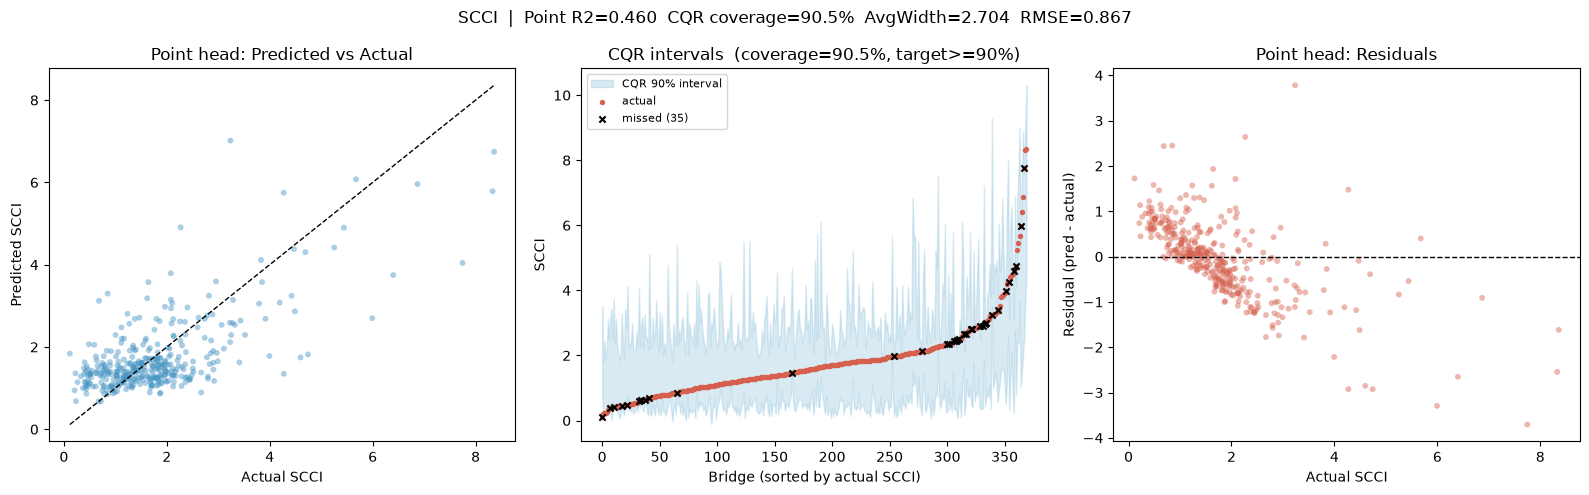

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.metrics import r2_score
from torch.utils.data import DataLoader, Subset


def collect_scci_preds(fold_idx):
    load_fold(fold_idx)
    loader = DataLoader(
        Subset(labeled_dataset, fold_states[fold_idx]['cal_idx']),
        batch_size=256, shuffle=False, pin_memory=False, num_workers=0,
    )
    q_los, q_his, pts, tgts = [], [], [], []
    with torch.no_grad():
        for batch in loader:
            num_x, cat_x, text_ids, y_scci, _ = [t.to(DEVICE) for t in batch]
            out   = model(num_x, cat_x, text_ids, mode='regress', alpha=ALPHA)
            valid = ~torch.isnan(y_scci)
            q_los.append((out['scci_direct']['q_lo'][valid] - Q_scci).cpu().numpy())
            q_his.append((out['scci_direct']['q_hi'][valid] + Q_scci).cpu().numpy())
            pts.append(out['scci_point'][valid].cpu().numpy())
            tgts.append(y_scci[valid].cpu().numpy())
    return (np.concatenate(q_los), np.concatenate(q_his),
            np.concatenate(pts),   np.concatenate(tgts))


all_qlo, all_qhi, all_pts, all_tgts, all_q = [], [], [], [], []
for fi in range(len(fold_states)):
    qlo, qhi, pts, tgts = collect_scci_preds(fi)
    all_qlo.append(qlo); all_qhi.append(qhi)
    all_pts.append(pts); all_tgts.append(tgts)
    all_q.append(fold_states[fi]['Q_scci'])

q_lo    = np.concatenate(all_qlo)
q_hi    = np.concatenate(all_qhi)
preds   = np.concatenate(all_pts)
targets = np.concatenate(all_tgts)
covered = (targets >= q_lo) & (targets <= q_hi)
mid     = (q_lo + q_hi) / 2

r2_pt  = r2_score(targets, preds)
r2_mid = r2_score(targets, mid)
rmse   = np.sqrt(np.mean((preds - targets) ** 2))
cov    = covered.mean()
width  = np.mean(q_hi - q_lo)

print(f'Point R2={r2_pt:.3f}  Mid R2={r2_mid:.3f}  RMSE={rmse:.3f}')
print(f'CQR coverage={cov:.1%} (target>=90%)  AvgWidth={width:.3f}')
print(f'Per-fold Q_scci: {[round(q, 4) for q in all_q]}')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    f'SCCI  |  Point R2={r2_pt:.3f}  CQR coverage={cov:.1%}  '
    f'AvgWidth={width:.3f}  RMSE={rmse:.3f}',
    fontsize=12,
)

ax = axes[0]
ax.scatter(targets, preds, alpha=0.45, s=18, color='#4393c3', edgecolors='none')
mn, mx = min(targets.min(), preds.min()), max(targets.max(), preds.max())
ax.plot([mn, mx], [mn, mx], 'k--', lw=1)
ax.set_xlabel('Actual SCCI'); ax.set_ylabel('Predicted SCCI')
ax.set_title('Point head: Predicted vs Actual')

ax = axes[1]
order  = np.argsort(targets)
xs     = np.arange(len(targets))
ax.fill_between(xs, q_lo[order], q_hi[order],
                alpha=0.35, color='#92c5de', label='CQR 90% interval')
ax.scatter(xs, targets[order], s=8, color='#d6604d', zorder=3, label='actual')
missed = ~covered[order]
ax.scatter(xs[missed], targets[order][missed], s=20, color='black',
           zorder=4, marker='x', label=f'missed ({missed.sum()})')
ax.set_xlabel('Bridge (sorted by actual SCCI)'); ax.set_ylabel('SCCI')
ax.set_title(f'CQR intervals  (coverage={cov:.1%}, target>=90%)')
ax.legend(fontsize=8)

ax = axes[2]
ax.scatter(targets, preds - targets, alpha=0.45, s=18,
           color='#d6604d', edgecolors='none')
ax.axhline(0, color='k', lw=1, linestyle='--')
ax.set_xlabel('Actual SCCI'); ax.set_ylabel('Residual (pred - actual)')
ax.set_title('Point head: Residuals')

plt.tight_layout()
plt.show()
load_fold(0)

In [8]:
from sklearn.metrics import r2_score
import numpy as np
import torch
from torch.utils.data import DataLoader, Subset

oof_pts  = np.full(len(labeled_dataset), np.nan)
oof_mids = np.full(len(labeled_dataset), np.nan)
oof_tgts = np.full(len(labeled_dataset), np.nan)

for fold_idx, fs in enumerate(fold_states):
    load_fold(fold_idx)
    cal_loader = DataLoader(Subset(labeled_dataset, fs['cal_idx']),
                            batch_size=256, shuffle=False,
                            pin_memory=False, num_workers=0)
    pts, mids, tgts, idxs = [], [], [], []
    row_ptr = 0
    with torch.no_grad():
        for batch in cal_loader:
            num_x, cat_x, text_ids, y_scci, _ = [t.to(DEVICE) for t in batch]
            out         = model(num_x, cat_x, text_ids, mode='regress', alpha=ALPHA)
            valid       = ~torch.isnan(y_scci)
            batch_size  = num_x.size(0)
            global_idxs = fs['cal_idx'][row_ptr:row_ptr + batch_size]
            row_ptr    += batch_size
            valid_cpu   = valid.cpu().numpy()
            pts.append(out['scci_point'][valid].cpu().numpy())
            q_lo = out['scci_direct']['q_lo'][valid]
            q_hi = out['scci_direct']['q_hi'][valid]
            mids.append(((q_lo + q_hi) / 2).cpu().numpy())
            tgts.append(y_scci[valid].cpu().numpy())
            idxs.extend([global_idxs[i] for i, v in enumerate(valid_cpu) if v])

    oof_pts[idxs]  = np.concatenate(pts)
    oof_mids[idxs] = np.concatenate(mids)
    oof_tgts[idxs] = np.concatenate(tgts)

valid_mask = ~np.isnan(oof_tgts)
oof_pts    = oof_pts[valid_mask]
oof_mids   = oof_mids[valid_mask]
oof_tgts   = oof_tgts[valid_mask]

r2_pt,  rmse_pt,  mae_pt  = (r2_score(oof_tgts, oof_pts),
                              np.sqrt(np.mean((oof_pts  - oof_tgts)**2)),
                              np.mean(np.abs(oof_pts  - oof_tgts)))
r2_mid, rmse_mid, mae_mid = (r2_score(oof_tgts, oof_mids),
                              np.sqrt(np.mean((oof_mids - oof_tgts)**2)),
                              np.mean(np.abs(oof_mids - oof_tgts)))

W = 60
print()
print('=' * W)
print(f'  SCCI Out-of-Fold Evaluation  ({valid_mask.sum()} rows, zero leakage)')
print('=' * W)
print(f"  {'Predictor':<14}  {'R2':>10}  {'RMSE':>10}  {'MAE':>10}")
print(f"  {'-'*48}")
print(f"  {'MSE head':<14}  {r2_pt:+.4f}      {rmse_pt:.4f}      {mae_pt:.4f}")
print(f"  {'Quantile mid':<14}  {r2_mid:+.4f}      {rmse_mid:.4f}      {mae_mid:.4f}")
print()
print('  Each row predicted by the 1 fold model that never trained on it.')

load_fold(0)


  SCCI Out-of-Fold Evaluation  (370 rows, zero leakage)
  Predictor               R2        RMSE         MAE
  ------------------------------------------------
  MSE head        +0.4601      0.8667      0.6332
  Quantile mid    +0.4270      0.8929      0.6874

  Each row predicted by the 1 fold model that never trained on it.


Total: 370  |  Shear-critical (SCCI<1.0): 82 (22.2%)


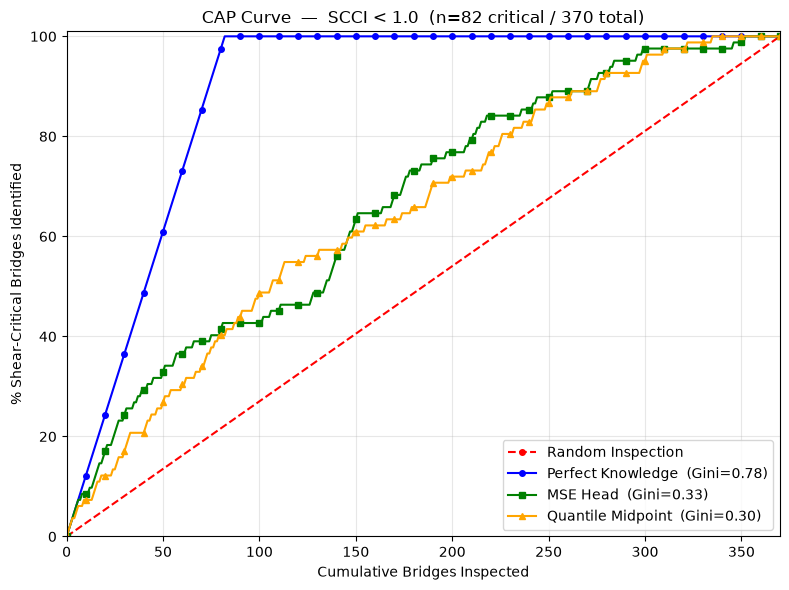

Gini coefficients:
  Perfect Knowledge : 0.7784
  MSE head          : 0.3283  (42.2% of perfect)
  Quantile midpoint : 0.2962  (38.1% of perfect)


In [9]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import DataLoader, Subset

SCCI_CRITICAL_THRESHOLD = 1.0

oof_pts  = np.full(len(labeled_dataset), np.nan)
oof_mids = np.full(len(labeled_dataset), np.nan)
oof_tgts = np.full(len(labeled_dataset), np.nan)

for fold_idx, fs in enumerate(fold_states):
    load_fold(fold_idx)
    cal_loader = DataLoader(Subset(labeled_dataset, fs['cal_idx']),
                            batch_size=256, shuffle=False,
                            pin_memory=False, num_workers=0)
    pts, mids, tgts, idxs = [], [], [], []
    row_ptr = 0
    with torch.no_grad():
        for batch in cal_loader:
            num_x, cat_x, text_ids, y_scci, _ = [t.to(DEVICE) for t in batch]
            out         = model(num_x, cat_x, text_ids, mode='regress', alpha=ALPHA)
            valid       = ~torch.isnan(y_scci)
            batch_size  = num_x.size(0)
            global_idxs = fs['cal_idx'][row_ptr:row_ptr + batch_size]
            row_ptr    += batch_size
            valid_cpu   = valid.cpu().numpy()
            pts.append(out['scci_point'][valid].cpu().numpy())
            q_lo = out['scci_direct']['q_lo'][valid]
            q_hi = out['scci_direct']['q_hi'][valid]
            mids.append(((q_lo + q_hi) / 2).cpu().numpy())
            tgts.append(y_scci[valid].cpu().numpy())
            idxs.extend([global_idxs[i] for i, v in enumerate(valid_cpu) if v])
    oof_pts[idxs]  = np.concatenate(pts)
    oof_mids[idxs] = np.concatenate(mids)
    oof_tgts[idxs] = np.concatenate(tgts)

valid_mask = ~np.isnan(oof_tgts)
pts_v   = oof_pts[valid_mask]
mids_v  = oof_mids[valid_mask]
tgts_v  = oof_tgts[valid_mask]
n_total = len(tgts_v)

is_critical = (tgts_v < SCCI_CRITICAL_THRESHOLD).astype(int)
n_critical  = is_critical.sum()
print(f'Total: {n_total}  |  Shear-critical (SCCI<{SCCI_CRITICAL_THRESHOLD}): {n_critical} ({100*n_critical/n_total:.1f}%)')


def cap_curve(scores_ascending, labels):
    order        = np.argsort(scores_ascending)
    cum_critical = np.cumsum(labels[order])
    x = np.arange(1, n_total + 1)
    y = cum_critical / n_critical * 100
    return np.concatenate([[0], x]), np.concatenate([[0], y])


def gini(x, y):
    rand_y = x / n_total * 100
    return np.trapezoid(y - rand_y, x) / np.trapezoid(100 - rand_y, x)


x_rand = np.array([0, n_total]); y_rand = np.array([0, 100])
x_perf, y_perf = cap_curve(tgts_v, is_critical)
x_pt,   y_pt   = cap_curve(pts_v,  is_critical)
x_mid,  y_mid  = cap_curve(mids_v, is_critical)

g_perf = gini(x_perf, y_perf)
g_pt   = gini(x_pt,   y_pt)
g_mid  = gini(x_mid,  y_mid)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(x_rand, y_rand, 'r--', marker='o', markersize=4, markevery=10,
        label='Random Inspection')
ax.plot(x_perf, y_perf, 'b-',  marker='o', markersize=4, markevery=10,
        label=f'Perfect Knowledge  (Gini={g_perf:.2f})')
ax.plot(x_pt,   y_pt,   'g-',  marker='s', markersize=4, markevery=10,
        label=f'MSE Head  (Gini={g_pt:.2f})')
ax.plot(x_mid,  y_mid,  color='orange', linestyle='-', marker='^',
        markersize=4, markevery=10,
        label=f'Quantile Midpoint  (Gini={g_mid:.2f})')

ax.set_xlabel('Cumulative Bridges Inspected')
ax.set_ylabel('% Shear-Critical Bridges Identified')
ax.set_title(
    f'CAP Curve  —  SCCI < {SCCI_CRITICAL_THRESHOLD}'
    f'  (n={n_critical} critical / {n_total} total)'
)
ax.legend(loc='lower right')
ax.set_xlim(0, n_total); ax.set_ylim(0, 101)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Gini coefficients:')
print(f'  Perfect Knowledge : {g_perf:.4f}')
print(f'  MSE head          : {g_pt:.4f}  ({100*g_pt/g_perf:.1f}% of perfect)')
print(f'  Quantile midpoint : {g_mid:.4f}  ({100*g_mid/g_perf:.1f}% of perfect)')

load_fold(0)